In [1]:
# ================================
# Fake News Detection
# ================================
# Step 1. Import libraries
import pandas as pd
import numpy as np
import string
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
# Step 2. Load datasets
fake_df = pd.read_csv('/content/Fake.csv')
true_df = pd.read_csv('/content/True.csv')


In [5]:
# Step 3. Add labels
fake_df['label'] = 0   # Fake
true_df['label'] = 1   # Real


In [6]:
# Step 4. Combine and shuffle
data = pd.concat([fake_df, true_df], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [7]:
# Optional: Check data info
print(data.head())

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2016       1  


In [8]:
# Step 5. Preprocess text
stop_words = set(stopwords.words('english'))

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [10]:
# Apply cleaning to 'title' + 'text' combined (or choose only 'title' for headline prediction)
data['content'] = data['title'] + " " + data['text']
data['content'] = data['content'].apply(clean_text)


In [11]:
# Step 6. Vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['content'])
y = data['label']


In [12]:
# Step 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
# Step 8. Train models

## Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [14]:
## Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [15]:
## Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [16]:
# Step 9. Evaluation function
def evaluate_model(y_test, y_pred, model_name):
    print(f"====== {model_name} ======")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


====== Logistic Regression ======
Accuracy: 0.9863028953229399
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



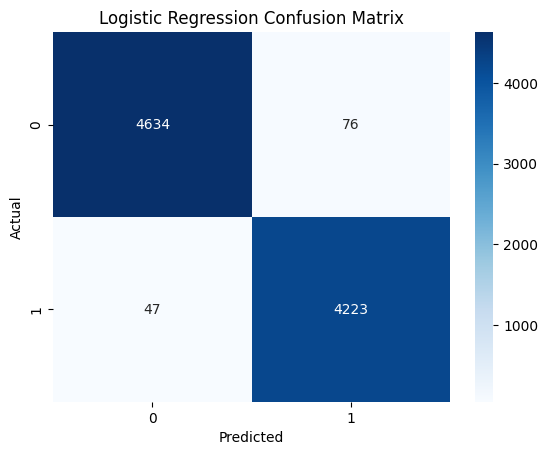

====== Naive Bayes ======
Accuracy: 0.9418708240534521
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94      4710
           1       0.93      0.94      0.94      4270

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



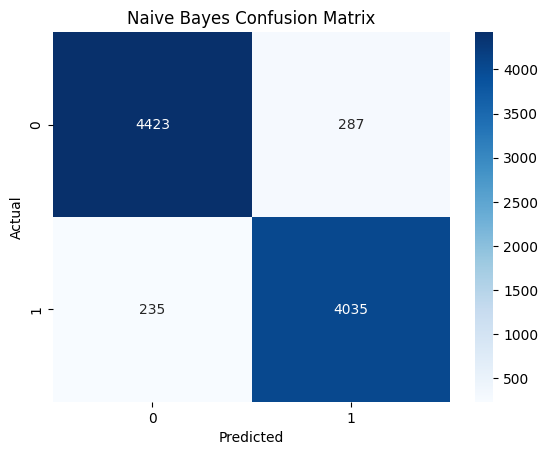

====== Random Forest ======
Accuracy: 0.9894209354120267
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4710
           1       0.99      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



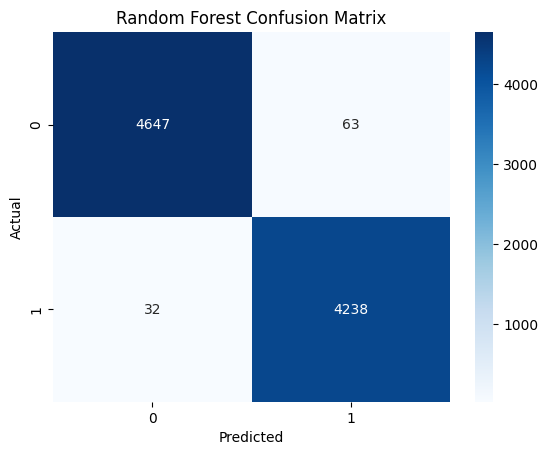

In [17]:
# Evaluate all models
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_rf, "Random Forest")

In [18]:
# Step 10. Prediction function for user input headline
def predict_news(news_headline):
    cleaned = clean_text(news_headline)
    vect = vectorizer.transform([cleaned])
    pred = lr.predict(vect)  # Using Logistic Regression by default
    if pred[0] == 0:
        print("Prediction: Fake News")
    else:
        print("Prediction: Real News")

# Example usage
predict_news("NASA announces discovery of water on Mars")

Prediction: Fake News
